In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import drive

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/glaucoma_handcrafted_features.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Mounted at /content/drive
Dataset Shape: (485, 13)

Columns:
['disc_area', 'cup_area', 'cup_disc_area_ratio', 'disc_perimeter', 'cup_perimeter', 'disc_width', 'disc_height', 'cup_width', 'cup_height', 'cup_disc_width_ratio', 'cup_disc_height_ratio', 'image_id', 'class']

First 5 Rows:


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [3]:
# Identify target column
if "class" in df.columns:
    target_column = "class"
elif "Class" in df.columns:
    target_column = "Class"
else:
    raise ValueError("Target column 'class' not found.")

# Remove image identifier columns
id_columns = []

for col in df.columns:
    if col.lower() in ["image_id", "image", "id", "filename"]:
        id_columns.append(col)

X_df = df.drop(columns=id_columns + [target_column]).copy()
y_raw = df[target_column].copy()

# Convert target to numerical labels
if y_raw.dtype == "object":
    class_mapping = {
        "glaucoma": 0,
        "normal": 1,
        "Glaucoma": 0,
        "Normal": 1
    }

    y = y_raw.map(class_mapping)

    # If mapping did not work, use generic categorical encoding
    if y.isna().any():
        unique_classes = sorted(y_raw.dropna().unique())
        generic_mapping = {
            value: index for index, value in enumerate(unique_classes)
        }
        y = y_raw.map(generic_mapping)

else:
    y = y_raw.astype(int)

# Make sure all feature columns are numerical
X_df = X_df.apply(pd.to_numeric, errors="coerce")

# Remove rows containing missing values
valid_rows = ~(X_df.isnull().any(axis=1) | y.isnull())

X_df = X_df.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True).astype(int)

print("Feature Matrix Shape:", X_df.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nFeatures:")
print(X_df.columns.tolist())

Feature Matrix Shape: (485, 11)
Target Shape: (485,)

Target Distribution:
class
1    313
0    172
Name: count, dtype: int64

Features:
['disc_area', 'cup_area', 'cup_disc_area_ratio', 'disc_perimeter', 'cup_perimeter', 'disc_width', 'disc_height', 'cup_width', 'cup_height', 'cup_disc_width_ratio', 'cup_disc_height_ratio']


In [4]:
def calculate_entropy(labels):
    """
    Calculate entropy of a categorical target variable.
    """

    labels = np.asarray(labels)

    if len(labels) == 0:
        return 0.0

    _, counts = np.unique(labels, return_counts=True)

    probabilities = counts / len(labels)

    entropy = 0.0

    for probability in probabilities:
        if probability > 0:
            entropy -= probability * np.log2(probability)

    return entropy


# Calculate dataset entropy
dataset_entropy = calculate_entropy(y)

print("Dataset Entropy:", round(dataset_entropy, 4))

Dataset Entropy: 0.9381


In [5]:
def calculate_gini(labels):
    """
    Calculate Gini impurity of a categorical target variable.
    """

    labels = np.asarray(labels)

    if len(labels) == 0:
        return 0.0

    _, counts = np.unique(labels, return_counts=True)

    probabilities = counts / len(labels)

    gini = 1.0 - np.sum(probabilities ** 2)

    return gini


dataset_gini = calculate_gini(y)

print("Dataset Gini Index:", round(dataset_gini, 4))

Dataset Gini Index: 0.4577


In [6]:
def bin_feature(values, binning_type="equal_width", n_bins=4):
    """
    Convert continuous values into categorical bins.

    Parameters
    ----------
    values : array-like
        Continuous feature values.

    binning_type : str
        'equal_width' or 'frequency'.

    n_bins : int
        Number of bins. Default = 4.
    """

    values = pd.Series(values)

    if n_bins < 2:
        raise ValueError("Number of bins must be at least 2.")

    if binning_type == "equal_width":

        min_value = values.min()
        max_value = values.max()

        if min_value == max_value:
            return pd.Series(
                np.zeros(len(values), dtype=int),
                index=values.index
            )

        edges = np.linspace(
            min_value,
            max_value,
            n_bins + 1
        )

        binned = pd.cut(
            values,
            bins=edges,
            labels=False,
            include_lowest=True
        )

    elif binning_type == "frequency":

        binned = pd.qcut(
            values,
            q=n_bins,
            labels=False,
            duplicates="drop"
        )

    else:
        raise ValueError(
            "binning_type must be 'equal_width' or 'frequency'"
        )

    return binned.astype(int)


# Test equal-width binning
test_feature = X_df.iloc[:, 0]

binned_feature = bin_feature(
    test_feature,
    binning_type="equal_width",
    n_bins=4
)

print("Original Values:")
print(test_feature.head(10).values)

print("\nBinned Values:")
print(binned_feature.head(10).values)

Original Values:
[179399 139202 146567  53820  81804  60220 198061 167626  86476  57953]

Binned Values:
[2 1 1 0 0 0 2 1 0 0]


In [7]:
def calculate_information_gain(feature, labels,
                               binning_type="equal_width",
                               n_bins=4):
    """
    Calculate Information Gain of a feature.

    Continuous features are first converted into
    categorical bins.
    """

    feature = pd.Series(feature).reset_index(drop=True)
    labels = pd.Series(labels).reset_index(drop=True)

    binned_feature = bin_feature(
        feature,
        binning_type=binning_type,
        n_bins=n_bins
    )

    parent_entropy = calculate_entropy(labels)

    weighted_entropy = 0.0

    for category in np.unique(binned_feature):

        subset_labels = labels[binned_feature == category]

        weight = len(subset_labels) / len(labels)

        subset_entropy = calculate_entropy(subset_labels)

        weighted_entropy += weight * subset_entropy

    information_gain = parent_entropy - weighted_entropy

    return information_gain

In [8]:
def find_root_feature(X, y,
                      binning_type="equal_width",
                      n_bins=4):
    """
    Find the feature having maximum Information Gain.
    """

    information_gains = {}

    for feature_name in X.columns:

        gain = calculate_information_gain(
            X[feature_name],
            y,
            binning_type=binning_type,
            n_bins=n_bins
        )

        information_gains[feature_name] = gain

    gain_table = pd.DataFrame(
        list(information_gains.items()),
        columns=["Feature", "Information Gain"]
    )

    gain_table = gain_table.sort_values(
        by="Information Gain",
        ascending=False
    ).reset_index(drop=True)

    root_feature = gain_table.iloc[0]["Feature"]

    return root_feature, gain_table


root_feature, gain_table = find_root_feature(
    X_df,
    y,
    binning_type="equal_width",
    n_bins=4
)

print("Root Feature:", root_feature)

print("\nInformation Gain for All Features:")
display(gain_table)

Root Feature: cup_disc_height_ratio

Information Gain for All Features:


,Feature,Information Gain
0,cup_disc_height_ratio,0.574823
1,cup_disc_area_ratio,0.455519
2,cup_perimeter,0.318239
3,cup_height,0.305433
4,cup_disc_width_ratio,0.296647
5,cup_width,0.249345
6,cup_area,0.171507
7,disc_width,0.041453
8,disc_perimeter,0.028284
9,disc_height,0.018010


In [9]:
root_equal, equal_gain_table = find_root_feature(
    X_df,
    y,
    binning_type="equal_width",
    n_bins=4
)

root_frequency, frequency_gain_table = find_root_feature(
    X_df,
    y,
    binning_type="frequency",
    n_bins=4
)

print("Root using Equal-Width Binning:")
print(root_equal)

print("\nRoot using Frequency Binning:")
print(root_frequency)

comparison = pd.DataFrame({
    "Feature": X_df.columns,
    "Equal Width IG": [
        calculate_information_gain(
            X_df[col],
            y,
            "equal_width",
            4
        )
        for col in X_df.columns
    ],
    "Frequency IG": [
        calculate_information_gain(
            X_df[col],
            y,
            "frequency",
            4
        )
        for col in X_df.columns
    ]
})

display(comparison)

Root using Equal-Width Binning:
cup_disc_height_ratio

Root using Frequency Binning:
cup_disc_height_ratio


,Feature,Equal Width IG,Frequency IG
0,disc_area,0.017557,0.022461
1,cup_area,0.171507,0.302823
2,cup_disc_area_ratio,0.455519,0.441983
3,disc_perimeter,0.028284,0.020970
4,cup_perimeter,0.318239,0.311168
5,disc_width,0.041453,0.028310
6,disc_height,0.018010,0.011277
7,cup_width,0.249345,0.244308
8,cup_height,0.305433,0.331605
9,cup_disc_width_ratio,0.296647,0.312332


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 339
Testing Samples: 146


In [11]:
class CustomDecisionTree:

    def __init__(
        self,
        max_depth=3,
        min_samples_split=2,
        n_bins=4,
        binning_type="equal_width"
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_bins = n_bins
        self.binning_type = binning_type
        self.tree = None

    def _majority_class(self, y):

        counter = Counter(y)

        return counter.most_common(1)[0][0]

    def _best_split(self, X, y):

        best_feature = None
        best_gain = -1

        for feature in X.columns:

            gain = calculate_information_gain(
                X[feature],
                y,
                self.binning_type,
                self.n_bins
            )

            if gain > best_gain:

                best_gain = gain
                best_feature = feature

        return best_feature, best_gain

    def _build_tree(self, X, y, depth):

        # Empty dataset
        if len(y) == 0:
            return None

        # All observations belong to one class
        if len(np.unique(y)) == 1:
            return {
                "type": "leaf",
                "class": int(y.iloc[0])
            }

        # Maximum depth reached
        if depth >= self.max_depth:
            return {
                "type": "leaf",
                "class": int(self._majority_class(y))
            }

        # Too few samples
        if len(y) < self.min_samples_split:
            return {
                "type": "leaf",
                "class": int(self._majority_class(y))
            }

        best_feature, best_gain = self._best_split(X, y)

        if best_feature is None or best_gain <= 0:
            return {
                "type": "leaf",
                "class": int(self._majority_class(y))
            }

        binned_values = bin_feature(
            X[best_feature],
            self.binning_type,
            self.n_bins
        )

        node = {
            "type": "node",
            "feature": best_feature,
            "gain": best_gain,
            "children": {}
        }

        for category in sorted(binned_values.unique()):

            mask = binned_values == category

            X_subset = X.loc[mask]
            y_subset = y.loc[mask]

            node["children"][int(category)] = self._build_tree(
                X_subset,
                y_subset,
                depth + 1
            )

        return node

    def fit(self, X, y):

        X = X.reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.tree = self._build_tree(
            X,
            y,
            depth=0
        )

        return self

    def _predict_one(self, row, node):

        if node["type"] == "leaf":
            return node["class"]

        feature = node["feature"]

        value = row[feature]

        binned_value = bin_feature(
            pd.Series([value]),
            self.binning_type,
            self.n_bins
        ).iloc[0]

        if int(binned_value) in node["children"]:

            child = node["children"][int(binned_value)]

            return self._predict_one(
                row,
                child
            )

        return 0

    def predict(self, X):

        predictions = []

        for _, row in X.iterrows():

            prediction = self._predict_one(
                row,
                self.tree
            )

            predictions.append(prediction)

        return np.array(predictions)

In [12]:
custom_tree = CustomDecisionTree(
    max_depth=4,
    min_samples_split=5,
    n_bins=4,
    binning_type="equal_width"
)

custom_tree.fit(X_train, y_train)

custom_predictions = custom_tree.predict(X_test)

custom_accuracy = accuracy_score(
    y_test,
    custom_predictions
)

print(
    "Custom Decision Tree Accuracy:",
    round(custom_accuracy * 100, 2),
    "%"
)

Custom Decision Tree Accuracy: 64.38 %


In [13]:
def print_custom_tree(node, level=0):

    indentation = "    " * level

    if node is None:
        return

    if node["type"] == "leaf":

        print(
            indentation +
            "Leaf -> Class:",
            node["class"]
        )

        return

    print(
        indentation +
        "Feature:",
        node["feature"],
        "| Information Gain:",
        round(node["gain"], 4)
    )

    for category, child in node["children"].items():

        print(
            indentation +
            f"  Bin {category}:"
        )

        print_custom_tree(
            child,
            level + 2
        )


print_custom_tree(custom_tree.tree)

Feature: cup_disc_height_ratio | Information Gain: 0.5174
  Bin 0:
        Leaf -> Class: 1
  Bin 1:
        Feature: cup_disc_height_ratio | Information Gain: 0.0341
          Bin 0:
                Leaf -> Class: 1
          Bin 1:
                Feature: disc_area | Information Gain: 0.2108
                  Bin 0:
                        Leaf -> Class: 1
                  Bin 1:
                        Leaf -> Class: 0
                  Bin 2:
                        Leaf -> Class: 1
                  Bin 3:
                        Leaf -> Class: 1
          Bin 2:
                Feature: cup_disc_height_ratio | Information Gain: 0.0905
                  Bin 0:
                        Leaf -> Class: 1
                  Bin 1:
                        Leaf -> Class: 1
                  Bin 2:
                        Feature: cup_disc_area_ratio | Information Gain: 0.7219
                          Bin 0:
                                Leaf -> Class: 1
                          Bin 

In [15]:
feature_1 = "cup_disc_area_ratio"
feature_2 = "cup_disc_width_ratio"

print("Feature 1:", feature_1)
print("Feature 2:", feature_2)

X_two = X_df[
    [feature_1, feature_2]
].copy()

X_two_train, X_two_test, y_two_train, y_two_test = train_test_split(
    X_two,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n2-Feature Dataset Shape:", X_two.shape)

Feature 1: cup_disc_area_ratio
Feature 2: cup_disc_width_ratio

2-Feature Dataset Shape: (485, 2)


In [16]:
two_feature_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

two_feature_tree.fit(
    X_two_train,
    y_two_train
)

two_predictions = two_feature_tree.predict(
    X_two_test
)

two_accuracy = accuracy_score(
    y_two_test,
    two_predictions
)

print(
    "2-Feature Decision Tree Accuracy:",
    round(two_accuracy * 100, 2),
    "%"
)

2-Feature Decision Tree Accuracy: 82.88 %


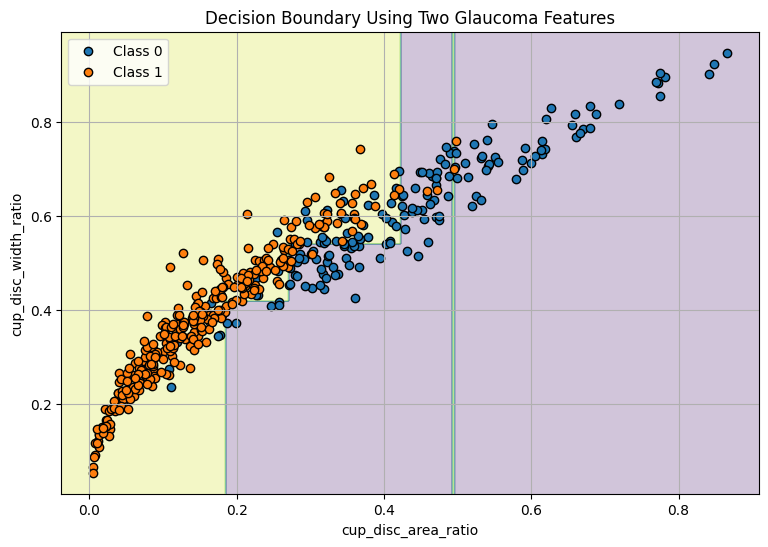

In [17]:
def plot_decision_boundary(
    model,
    X,
    y,
    feature_names,
    title
):

    x_min = X.iloc[:, 0].min()
    x_max = X.iloc[:, 0].max()

    y_min = X.iloc[:, 1].min()
    y_max = X.iloc[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    xx, yy = np.meshgrid(
        np.linspace(
            x_min - 0.05 * x_range,
            x_max + 0.05 * x_range,
            300
        ),
        np.linspace(
            y_min - 0.05 * y_range,
            y_max + 0.05 * y_range,
            300
        )
    )

    grid = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=feature_names
    )

    predictions = model.predict(grid)

    predictions = predictions.reshape(
        xx.shape
    )

    plt.figure(figsize=(9, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )

    for class_value in sorted(y.unique()):

        mask = y == class_value

        plt.scatter(
            X.loc[mask, feature_names[0]],
            X.loc[mask, feature_names[1]],
            label=f"Class {class_value}",
            edgecolor="black"
        )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()


plot_decision_boundary(
    two_feature_tree,
    X_two,
    y,
    [feature_1, feature_2],
    "Decision Boundary Using Two Glaucoma Features"
)

In [19]:
param_grid = {
    "criterion": [
        "gini",
        "entropy"
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "\nBest Cross-Validation Accuracy:",
    round(
        grid_search.best_score_ * 100,
        2
    ),
    "%"
)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy: 90.55 %


In [20]:
best_tree = grid_search.best_estimator_

tuned_predictions = best_tree.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

print(
    "Tuned Decision Tree Test Accuracy:",
    round(
        tuned_accuracy * 100,
        2
    ),
    "%"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        tuned_predictions
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "Glaucoma",
            "Normal"
        ]
    )
)

Tuned Decision Tree Test Accuracy: 91.1 %

Confusion Matrix:
[[43  9]
 [ 4 90]]

Classification Report:
              precision    recall  f1-score   support

    Glaucoma       0.91      0.83      0.87        52
      Normal       0.91      0.96      0.93        94

    accuracy                           0.91       146
   macro avg       0.91      0.89      0.90       146
weighted avg       0.91      0.91      0.91       146



In [22]:
results = pd.DataFrame({
    "Experiment": [
        "Dataset Entropy",
        "Dataset Gini Index",
        "Custom Decision Tree",
        "2-Feature Decision Tree",
        "GridSearchCV Decision Tree"
    ],

    "Result": [
        round(dataset_entropy, 4),
        round(dataset_gini, 4),
        round(custom_accuracy * 100, 2),
        round(two_accuracy * 100, 2),
        round(tuned_accuracy * 100, 2)
    ],

    "Unit": [
        "Entropy",
        "Gini",
        "%",
        "%",
        "%"
    ]
})

display(results)

,Experiment,Result,Unit
0,Dataset Entropy,0.9381,Entropy
1,Dataset Gini Index,0.4577,Gini
2,Custom Decision Tree,64.3800,%
3,2-Feature Decision Tree,82.8800,%
4,GridSearchCV Decision Tree,91.1000,%
